<a href="https://www.kaggle.com/code/valentinorayisabell/notebook395739ed81?scriptVersionId=313169211" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/llm-classification-finetuning/sample_submission.csv
/kaggle/input/competitions/llm-classification-finetuning/train.csv
/kaggle/input/competitions/llm-classification-finetuning/test.csv


In [ ]:
# ── CELL 1: Install ────────────────────────────────────────────────────────
import subprocess
subprocess.run(['pip', 'install', '-q', 'transformers', 'datasets', 'accelerate', 'scikit-learn'], check=True)
print('✅ Done')

In [2]:
# ── CELL 2: Imports ────────────────────────────────────────────────────────
import os, glob, json, gc, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModel,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer, TrainingArguments,
    get_cosine_schedule_with_warmup
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import log_loss
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_CUDA = torch.cuda.is_available()
print(f'✅ Device: {DEVICE}')
if USE_CUDA:
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')# ── CELL 2: Imports ────────────────────────────────────────────────────────
import os, glob, json, gc, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModel,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer, TrainingArguments,
    get_cosine_schedule_with_warmup
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import log_loss
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_CUDA = torch.cuda.is_available()
print(f'✅ Device: {DEVICE}')
if USE_CUDA:
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

✅ Device: cpu
✅ Device: cpu


In [4]:
# ── CELL 3: Config ─────────────────────────────────────────────────────────
CFG = {
    # Model
    'model_name':   'microsoft/deberta-v3-base',  # base > small for leaderboard
    'max_len':      512,
    'num_labels':   3,

    # Training
    'epochs':       3,
    'batch_size':   8,
    'grad_accum':   4,       # effective batch = 32
    'lr':           2e-5,
    'weight_decay': 0.01,
    'warmup_ratio': 0.1,
    'dropout':      0.1,
    'seed':         42,

    # CV
    'n_folds':      5,

    # Inference
    'infer_batch':          16,
    'swap_average':         True,   # position bias fix
    'temperature':          1.0,    # tuned via calibration
    'temp_search':          [0.5, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.5, 2.0],

    # Paths
    'output_dir':   '/kaggle/working',
    'fp16':         True,
}

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(CFG['seed'])
print('✅ Config ready')

✅ Config ready


In [5]:
# ── CELL 4: Dynamic Data Path Resolution (from public notebook) ────────────
def resolve_data_dir():
    need = {'train.csv', 'test.csv', 'sample_submission.csv'}
    candidates = [
        '/kaggle/input/llm-classification-finetuning',
        '/kaggle/input/competitions/llm-classification-finetuning',
    ]
    for d in candidates:
        if os.path.isdir(d) and need.issubset(set(os.listdir(d))):
            return d
    for dirpath, _, filenames in os.walk('/kaggle/input'):
        if need.issubset(set(filenames)):
            return dirpath
    raise FileNotFoundError('train.csv not found — attach competition data in notebook settings.')

DATA_DIR = resolve_data_dir()
print(f'✅ Data found at: {DATA_DIR}')

train_df  = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
test_df   = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))
sample_sub = pd.read_csv(os.path.join(DATA_DIR, 'sample_submission.csv'))

print(f'Train: {train_df.shape} | Test: {test_df.shape}')
print(f'Train cols: {train_df.columns.tolist()}')

✅ Data found at: /kaggle/input/competitions/llm-classification-finetuning
Train: (57477, 9) | Test: (3, 4)
Train cols: ['id', 'model_a', 'model_b', 'prompt', 'response_a', 'response_b', 'winner_model_a', 'winner_model_b', 'winner_tie']


[check] prob_sum_ok_ratio: 1.0000


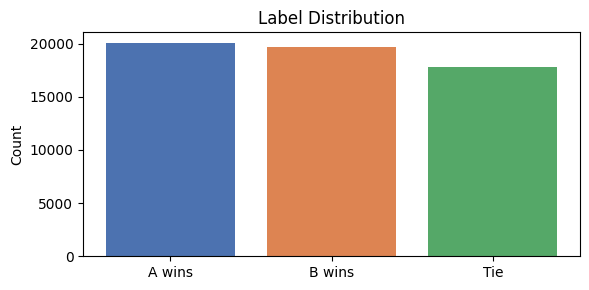

Labels: {0: np.int64(20064), 1: np.int64(19652), 2: np.int64(17761)}


In [6]:
# ── CELL 5: Label Encoding + Validation ────────────────────────────────────
def winner_to_label(df):
    """Convert one-hot winner columns to integer label with validation."""
    cols = ['winner_model_a', 'winner_model_b', 'winner_tie']
    w = df[cols].values.astype(np.float32)
    s = w.sum(axis=1)
    ok = np.isclose(s, 1.0, atol=1e-3)
    print(f'[check] prob_sum_ok_ratio: {ok.mean():.4f}')
    if not np.all(ok):
        raise ValueError('winner columns must sum to 1 per row')
    return w.argmax(axis=1)   # 0=A wins, 1=B wins, 2=tie

train_df['label'] = winner_to_label(train_df)

# Label distribution plot
vc = train_df['label'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6,3))
ax.bar(['A wins','B wins','Tie'], [vc.get(0,0), vc.get(1,0), vc.get(2,0)],
       color=['#4C72B0','#DD8452','#55A868'])
ax.set_title('Label Distribution')
ax.set_ylabel('Count')
fig.tight_layout()
fig.savefig(f"{CFG['output_dir']}/label_distribution.png", dpi=120)
plt.show()
print(f'Labels: {dict(vc)}')

In [7]:
# ── CELL 6: Text Builder + Feature Engineering ─────────────────────────────
def build_pair_text(prompt, response_a, response_b):
    """Build classifier input from public notebook — clean and structured."""
    return (
        f"Which response do judges prefer?\n\n"
        f"### Prompt\n{str(prompt)}\n\n"
        f"### Response A\n{str(response_a)}\n\n"
        f"### Response B\n{str(response_b)}"
    )

def add_meta_features(df):
    """Extra features for analysis — not fed to model but useful for debugging."""
    df = df.copy()
    df['len_a']     = df['response_a'].astype(str).str.len()
    df['len_b']     = df['response_b'].astype(str).str.len()
    df['len_ratio'] = df['len_a'] / (df['len_b'] + 1)
    df['len_diff']  = df['len_a'] - df['len_b']
    confidence_words = ['certainly','definitely','clearly','obviously']
    hedge_words      = ['maybe','perhaps','might','possibly','unsure']
    for col, name in [('response_a','a'),('response_b','b')]:
        t = df[col].astype(str).str.lower()
        df[f'conf_{name}'] = sum(t.str.count(w) for w in confidence_words)
        df[f'hedge_{name}'] = sum(t.str.count(w) for w in hedge_words)
    return df

train_df = add_meta_features(train_df)
test_df  = add_meta_features(test_df)
print('✅ Features built')
print(train_df[['len_a','len_b','len_ratio']].describe().round(1))

✅ Features built
         len_a    len_b  len_ratio
count  57477.0  57477.0    57477.0
mean    1377.8   1386.2        2.0
std     1513.9   1537.8        8.5
min        4.0      4.0        0.0
25%      408.0    413.0        0.6
50%     1076.0   1086.0        1.0
75%     1862.0   1873.0        1.6
max    54058.0  53830.0      973.2


In [8]:
# ── CELL 7: Dataset ────────────────────────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained(CFG['model_name'])

class PairDataset(Dataset):
    def __init__(self, df, tokenizer, max_len, is_test=False):
        self.df        = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len   = max_len
        self.is_test   = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        text = build_pair_text(row['prompt'], row['response_a'], row['response_b'])
        enc  = self.tokenizer(
            text,
            max_length=self.max_len,
            truncation=True,
            padding=False,
            return_tensors=None
        )
        item = {k: torch.tensor(v) for k, v in enc.items()}
        if not self.is_test:
            item['labels'] = torch.tensor(int(row['label']), dtype=torch.long)
        return item

print('✅ Dataset ready')

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

✅ Dataset ready


In [9]:
# ── CELL 8: Log Loss Metric for Trainer ────────────────────────────────────
def softmax_np(x, axis=-1):
    x = x - np.max(x, axis=axis, keepdims=True)
    e = np.exp(x)
    return e / np.sum(e, axis=axis, keepdims=True)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = softmax_np(logits)
    preds = np.argmax(logits, axis=-1)
    acc   = float((preds == labels).mean())
    # One-hot labels for log_loss
    n = len(labels)
    y_onehot = np.zeros((n, 3))
    y_onehot[np.arange(n), labels] = 1
    ll = log_loss(y_onehot, probs)
    return {'accuracy': acc, 'log_loss': ll}

print('✅ Metrics ready — tracking BOTH accuracy and log_loss')

✅ Metrics ready — tracking BOTH accuracy and log_loss


In [10]:
# ── CELL 9: Temperature Calibration ───────────────────────────────────────
@torch.no_grad()
def get_val_logits(model, val_df, tokenizer, max_len, batch_size, device):
    model.eval()
    all_logits = []
    for start in range(0, len(val_df), batch_size):
        batch = val_df.iloc[start:start+batch_size]
        texts = [build_pair_text(r.prompt, r.response_a, r.response_b)
                 for r in batch.itertuples(index=False)]
        enc = tokenizer(texts, max_length=max_len, truncation=True,
                        padding=True, return_tensors='pt')
        enc = {k: v.to(device) for k, v in enc.items()}
        logits = model(**enc).logits.float().cpu().numpy()
        all_logits.append(logits)
    return np.vstack(all_logits)

def calibrate_temperature(logits, labels, temps):
    """Grid search best temperature on val set."""
    n = len(labels)
    y_onehot = np.zeros((n, 3))
    y_onehot[np.arange(n), labels] = 1
    best_temp, best_ll = 1.0, float('inf')
    print('\nCalibrating temperature:')
    for t in temps:
        probs = softmax_np(logits / t)
        ll    = log_loss(y_onehot, probs)
        print(f'  temp={t:.2f} → log_loss={ll:.5f}')
        if ll < best_ll:
            best_ll   = ll
            best_temp = t
    print(f'✅ Best temp: {best_temp} (log_loss: {best_ll:.5f})')
    return best_temp

print('✅ Calibration functions ready')

✅ Calibration functions ready


In [11]:
# ── CELL 10: Inference with Position Bias Fix ──────────────────────────────
@torch.no_grad()
def predict_probs(model, df, tokenizer, max_len, batch_size, device,
                  temperature=1.0, swap_average=True):
    model.eval()
    n     = len(df)
    probs = np.zeros((n, 3), dtype=np.float64)

    for start in range(0, n, batch_size):
        batch = df.iloc[start:start+batch_size]

        # Normal order
        texts = [build_pair_text(r.prompt, r.response_a, r.response_b)
                 for r in batch.itertuples(index=False)]
        enc = tokenizer(texts, max_length=max_len, truncation=True,
                        padding=True, return_tensors='pt')
        enc = {k: v.to(device) for k, v in enc.items()}
        logits = model(**enc).logits.float().cpu().numpy()
        p = softmax_np(logits / temperature)

        if swap_average:
            # Swapped order — eliminates position bias
            texts_sw = [build_pair_text(r.prompt, r.response_b, r.response_a)
                        for r in batch.itertuples(index=False)]
            enc2 = tokenizer(texts_sw, max_length=max_len, truncation=True,
                             padding=True, return_tensors='pt')
            enc2 = {k: v.to(device) for k, v in enc2.items()}
            logits2 = model(**enc2).logits.float().cpu().numpy()
            p2 = softmax_np(logits2 / temperature)
            p2_swapped = p2[:, [1, 0, 2]]   # flip A/B columns back
            p = (p + p2_swapped) / 2.0

        probs[start:start+len(batch)] = p

    return probs

print('✅ Inference function ready')

✅ Inference function ready


In [ ]:
# ── CELL 11: Cross-Validation Training Loop ────────────────────────────────
collator   = DataCollatorWithPadding(tokenizer=tokenizer)
skf        = StratifiedKFold(n_splits=CFG['n_folds'], shuffle=True, random_state=CFG['seed'])
oof_probs  = np.zeros((len(train_df), 3))   # out-of-fold predictions
fold_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(train_df, train_df['label'])):
    print(f'\n══════════════════════════════')
    print(f'  FOLD {fold+1}/{CFG["n_folds"]}')
    print(f'══════════════════════════════')

    fold_train = train_df.iloc[train_idx].reset_index(drop=True)
    fold_val   = train_df.iloc[val_idx].reset_index(drop=True)

    train_ds = PairDataset(fold_train, tokenizer, CFG['max_len'])
    val_ds   = PairDataset(fold_val,   tokenizer, CFG['max_len'])

    model = AutoModelForSequenceClassification.from_pretrained(
        CFG['model_name'], num_labels=CFG['num_labels']
    )

    training_args = TrainingArguments(
        output_dir=f"{CFG['output_dir']}/fold{fold}",
        num_train_epochs=CFG['epochs'],
        per_device_train_batch_size=CFG['batch_size'],
        per_device_eval_batch_size=CFG['batch_size'] * 2,
        gradient_accumulation_steps=CFG['grad_accum'],
        learning_rate=CFG['lr'],
        weight_decay=CFG['weight_decay'],
        warmup_ratio=CFG['warmup_ratio'],
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='log_loss',   # ← competition metric
        greater_is_better=False,
        logging_steps=50,
        save_total_limit=1,
        seed=CFG['seed'],
        fp16=CFG['fp16'],
        report_to='none',
        dataloader_pin_memory=USE_CUDA,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        data_collator=collator,
        compute_metrics=compute_metrics,
    )

    trainer.train()

    # ── Temperature calibration on this fold's val set ──
    val_logits = get_val_logits(
        model, fold_val, tokenizer,
        CFG['max_len'], CFG['infer_batch'], DEVICE
    )
    best_temp = calibrate_temperature(
        val_logits, fold_val['label'].values, CFG['temp_search']
    )
    CFG[f'temp_fold{fold}'] = best_temp

    # ── OOF predictions with best temp + swap fix ──
    fold_probs = predict_probs(
        model, fold_val, tokenizer,
        CFG['max_len'], CFG['infer_batch'], DEVICE,
        temperature=best_temp, swap_average=CFG['swap_average']
    )
    oof_probs[val_idx] = fold_probs

    # ── Fold score ──
    val_labels = fold_val['label'].values
    n = len(val_labels)
    y_oh = np.zeros((n, 3)); y_oh[np.arange(n), val_labels] = 1
    fold_ll = log_loss(y_oh, fold_probs)
    fold_scores.append(fold_ll)
    print(f'\n✅ Fold {fold+1} Log Loss: {fold_ll:.5f}')

    # ── Save model adapter ──
    model.save_pretrained(f"{CFG['output_dir']}/model_fold{fold}")
    tokenizer.save_pretrained(f"{CFG['output_dir']}/model_fold{fold}")

    del model, trainer
    gc.collect()
    torch.cuda.empty_cache()

# ── OOF Summary ──
n = len(train_df)
y_oh = np.zeros((n, 3)); y_oh[np.arange(n), train_df['label'].values] = 1
oof_ll = log_loss(y_oh, oof_probs)
print(f'\n══════════════════════════════')
print(f'CV RESULTS')
print(f'══════════════════════════════')
for i, s in enumerate(fold_scores):
    print(f'  Fold {i+1}: {s:.5f}')
print(f'  Mean:   {np.mean(fold_scores):.5f}')
print(f'  OOF:    {oof_ll:.5f}')
np.save(f"{CFG['output_dir']}/oof_probs.npy", oof_probs)


══════════════════════════════
  FOLD 1/5
══════════════════════════════


pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.bias          

model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

In [ ]:
# ── CELL 12: Training History Plot ────────────────────────────────────────
# Plot fold scores
fig, ax = plt.subplots(figsize=(7,3))
ax.bar([f'Fold {i+1}' for i in range(len(fold_scores))], fold_scores, color='#4C72B0')
ax.axhline(np.mean(fold_scores), color='red', linestyle='--', label=f'Mean: {np.mean(fold_scores):.5f}')
ax.set_title('Log Loss per Fold')
ax.set_ylabel('Log Loss')
ax.legend()
fig.tight_layout()
fig.savefig(f"{CFG['output_dir']}/fold_scores.png", dpi=120)
plt.show()
print('✅ Plot saved')

In [ ]:
# ── CELL 13: Ensemble Test Predictions Across All Folds ───────────────────
from transformers import AutoModelForSequenceClassification as AMSC

test_probs_all = []

for fold in range(CFG['n_folds']):
    print(f'\nInference — Fold {fold+1}/{CFG["n_folds"]}')
    model_path = f"{CFG['output_dir']}/model_fold{fold}"
    model = AMSC.from_pretrained(model_path).to(DEVICE)
    temp  = CFG.get(f'temp_fold{fold}', 1.0)

    fold_test_probs = predict_probs(
        model, test_df, tokenizer,
        CFG['max_len'], CFG['infer_batch'], DEVICE,
        temperature=temp, swap_average=CFG['swap_average']
    )
    test_probs_all.append(fold_test_probs)
    print(f'  ✅ Fold {fold+1} done | temp={temp}')

    del model
    gc.collect()
    torch.cuda.empty_cache()

# Average across folds
final_probs = np.mean(test_probs_all, axis=0)
print(f'\n✅ Ensemble shape: {final_probs.shape}')
print(f'   Prob sum check — mean: {final_probs.sum(axis=1).mean():.5f}')

In [ ]:
# ── CELL 14: Build Submission with ID Alignment Check ─────────────────────
def norm_id(s):
    return s.astype(str).str.strip()

tid = norm_id(test_df['id'])
sid = norm_id(sample_sub['id'])

# Duplicate check
if tid.duplicated().any():
    raise ValueError('Duplicate IDs in test.csv')

# Alignment check
idx_by_id   = {t: i for i, t in enumerate(tid)}
missing_ids = [x for x in sid.tolist() if x not in idx_by_id]
if missing_ids:
    raise ValueError(f'IDs in sample_submission not found in test: {missing_ids[:5]}')

# Reorder to match sample_submission
order_idx = np.array([idx_by_id[x] for x in sid.tolist()], dtype=np.int64)

sub = sample_sub[['id']].copy()
sub['winner_model_a'] = final_probs[order_idx, 0]
sub['winner_model_b'] = final_probs[order_idx, 1]
sub['winner_tie']     = final_probs[order_idx, 2]

# Final sanity checks
row_sums = sub[['winner_model_a','winner_model_b','winner_tie']].sum(axis=1)
assert row_sums.between(0.99, 1.01).all(), 'Probs dont sum to 1!'
assert len(sub) == len(sample_sub), 'Row count mismatch!'

sub.to_csv('/kaggle/working/submission.csv', index=False)
print('✅ submission.csv saved')
print(f'   Shape: {sub.shape}')
print(f'   Prob sum — mean: {row_sums.mean():.5f} | min: {row_sums.min():.5f} | max: {row_sums.max():.5f}')
print('\n── Sample predictions ──')
print(sub.head(10).to_string(index=False))